# Loading libraries

In [41]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

In [42]:
from spatial_lda.featurization import neighborhood_to_cluster
from spatial_lda.featurization import make_nearest_neighbor_graph
from spatial_lda.featurization import make_difference_matrix
from spatial_lda.featurization import make_merged_difference_matrices
from spatial_lda.featurization import featurize_spleens
from spatial_lda.visualization import plot_samples_in_a_row
from spatial_lda.visualization import plot_bcell_topic_multicolor
from spatial_lda.visualization import plot_adjacency_graph

import spatial_lda.model
from spatial_lda.model import order_topics_consistently

In [43]:
N_PARALLEL_PROCESSES = 8
TRAIN_SIZE_FRACTION = 0.99
N_TOPICS_LIST = [3, 5, 8, 10]

# Loading data

In [44]:
PATH_TO_MODELS = f'../models/'
PATH_TO_SPLEEN_DF_PKL = f'../data/spleen/spleen_df.pkl'
PATH_TO_SPLEEN_FEATURES_PKL = f'../data/spleen/spleen_cells_features.pkl'

paths = [
  PATH_TO_MODELS,
  PATH_TO_SPLEEN_DF_PKL
]

In [45]:
codex_df_dict = pd.read_pickle(PATH_TO_SPLEEN_DF_PKL)

# used for visualization later
for df in codex_df_dict.values():
  df['x'] = df['sample.X']
  df['y'] = df['sample.Y']

* `spleen_dfs` is a dictionary of all wild-type samples (values are dataframes)
* Dataframes carry spatial coordinates, measurements for different biomarkers, and an indicator for whether a cell is a B cell.

In [46]:
## Getting names of wild-type observations
wt_samples = [x for x in codex_df_dict.keys() if x.startswith("BALBc")]

## Creating a dictionary for the wild-type observations 
spleen_dfs = dict(zip(wt_samples, [ codex_df_dict[x] for x in wt_samples]))

In [47]:
spleen_dfs["BALBc-1"].head()

,Imaging phenotype cluster ID,CD45,Ly6C,TCR,Ly6G,CD19,CD169,CD106,CD3,CD1632,...,sample,Xtile,Ytile,sample.X,sample.Y,sample.Z,cluster,isb,x,y
7,9600,5666.397949,-155.011398,-427.121613,-53.596302,696.744141,-488.727325,349.676666,-450.499329,805.963440,...,BALBc-1,1,5,2392,5646,28.723404,CD11c(+) B cells,True,2392,5646
10,9600,7034.170898,-161.461090,738.726929,-52.546940,1373.622925,-636.755981,1856.957031,-443.563812,2390.583252,...,BALBc-1,2,5,3783,5471,33.510638,CD11c(+) B cells,True,3783,5471
14,9600,1873.250610,381.250488,502.290131,205.504501,803.336243,-153.537766,-668.360718,-142.203369,-294.623016,...,BALBc-1,2,9,3790,9311,9.574468,CD11c(+) B cells,True,3790,9311
16,9600,3770.339111,-91.655739,-760.648010,-44.789978,362.723816,-390.926819,269.888702,-354.102997,598.464417,...,BALBc-1,1,4,2406,4963,19.148936,CD11c(+) B cells,True,2406,4963
20,9600,9060.431641,-186.782639,1443.815308,-19.553146,2401.723389,-1091.332275,4447.319824,-1541.089600,3990.296387,...,BALBc-1,3,1,5182,2014,33.510638,CD11c(+) B cells,True,5182,2014


# Featurization

In short, "featurization" here refers to constructing documents.

* Again, each document corresponds to a 100-px radius neighborhood around some
  B cell. 
* The words in the document are cell types, e.g. `CD4(+)`, `CD8(+)`, `erythroblasts`.
  Under the bag of words assumption, we only care about the counts of different
  words (cell types).
* `spleen_cell_features` is a single data frame where the indices are of the
  form `(BALBc-{sample}, {index_of_B_cell})`.
* There are 24 columns (cell types).

In [48]:
spleen_cells_features = featurize_spleens(
    spleen_dfs=spleen_dfs, 
    neighborhood_feature_fn=neighborhood_to_cluster, 
    radius=100,                                        
    n_processes=N_PARALLEL_PROCESSES)

100%|██████████| 3/3 [00:06<00:00,  2.14s/it]


In [49]:
spleen_cells_features.head()

cluster,CD4(+) T cells,CD8(+) T cells,CD106(+)CD16/32(+)CD31(-)Ly6C(-) stroma,CD4(-)CD8(-) cDC,F4/80(+) mphs,erythroblasts,CD4(-)CD8(+)cDC,plasma cells,CD106(-)CD16/32(+)Ly6C(+)CD31(-),CD106(+)CD16/32(-)Ly6C(+)CD31(+),...,NK cells,CD106(+)CD16/32(+)CD31(+) stroma,CD4(+)MHCII(+),B220(+) DN T cells,CD3(+) other markers (-),capsule,megakaryocytes,FDCs,CD31(hi) vascular,CD106(-)CD16/32(-)Ly6C(+)CD31(+) stroma
"(BALBc-1, 7)",16.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-1, 10)",5.0,2.0,0.0,0.0,4.0,3.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-1, 14)",1.0,4.0,0.0,0.0,8.0,5.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-1, 16)",21.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-1, 20)",6.0,0.0,3.0,0.0,8.0,3.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In `BALBc-1`, there are 35,271 B cells. 

In [50]:
spleen_cells_features[spleen_cells_features.index.map(lambda x: x[0]) == "BALBc-1"].shape

(35271, 24)

The following cell computes difference matrices.

* `make_merged_difference_matrices` does the following:
  - For each sample, e.g. `BALBc-1`, build the Voronoi graph with `make_nearest_neighbor_graph`. The function returns
    - number of nodes
    - list of source nodes
    - list of destination nodes
    - lengths of each edge
  - Using the number of nodes and lists of source and destination nodes, build
    a difference matrix with `make_difference_matrix`.
    - e.g. suppose we have a graph with 4 nodes and edges given by
    
      ```
      [[0, 1],              3 -- 2
       [0, 2],              |  / 
       [0, 3],              | /
       [2, 3]]              0 -- 1
      ```
      The corresponding difference matrix is given below:


In [51]:
ex_src_nodes = [0, 0, 0, 2]
ex_dst_nodes = [1, 2, 3, 3]
ex_num_nodes = 4

In [52]:
make_difference_matrix(ex_num_nodes, ex_src_nodes, ex_dst_nodes).toarray()

array([[ 1., -1.,  0.,  0.],
       [ 1.,  0., -1.,  0.],
       [ 1.,  0.,  0., -1.],
       [ 0.,  0.,  1., -1.]])

In [53]:
spleen_difference_matrices = make_merged_difference_matrices(
    sample_features=spleen_cells_features,
    sample_dfs=spleen_dfs,
    x_col='sample.X', 
    y_col='sample.Y') 

In [54]:
spleen_difference_matrices

{'BALBc-3': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 64152 stored elements and shape (32076, 32077)>,
 'BALBc-1': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 70540 stored elements and shape (35270, 35271)>,
 'BALBc-2': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 66982 stored elements and shape (33491, 33492)>}

In [55]:
spleen_difference_matrices["BALBc-1"].max()

np.float64(1.0)

A test/train split is performed here. The test split does not get used for 
anything later on (reason unclear).

In [56]:
all_sample_idxs = spleen_cells_features.index.map(lambda x: x[0])

# Stratification ensures that training and test have similar sample-level
# proportions
_sets = train_test_split(spleen_cells_features, 
                         test_size=1. - TRAIN_SIZE_FRACTION,
                         stratify=all_sample_idxs)

train_spleen_cells_features, test_spleen_cells_features = _sets

In [57]:
train_difference_matrices = make_merged_difference_matrices(
    sample_features=train_spleen_cells_features, 
    sample_dfs=spleen_dfs,
    x_col='sample.X', 
    y_col='sample.Y')

spleen_idxs = train_spleen_cells_features.index.map(lambda x: x[0])

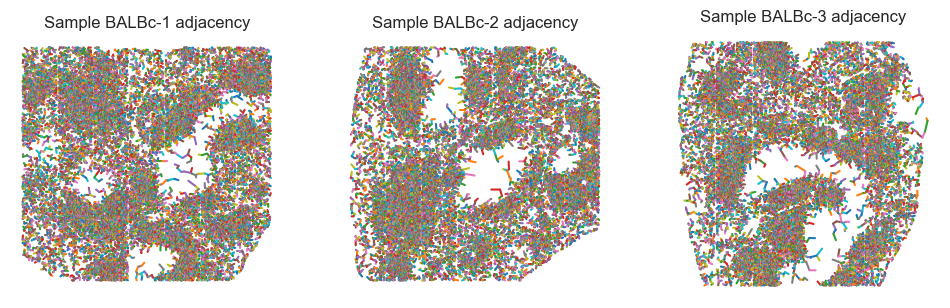

In [58]:
def make_plot_fn(difference_matrices):  
    def plot_fn(ax, tumor_idx, features_df, patient_dfs):
        plot_adjacency_graph(ax, tumor_idx, features_df, patient_dfs, difference_matrices)
    return plot_fn

_plot_fn = make_plot_fn(spleen_difference_matrices)

plot_samples_in_a_row(spleen_cells_features, _plot_fn, spleen_dfs, tumor_set=['BALBc-1', 'BALBc-2', 'BALBc-3'])

# Training

Training models with $K=3,5,8,10$ took roughly 50 minutes altogether on an M4 MacBook Pro with 24 gb of RAM.

In [64]:
train_spleen_cells_features

cluster,CD4(+) T cells,CD8(+) T cells,CD106(+)CD16/32(+)CD31(-)Ly6C(-) stroma,CD4(-)CD8(-) cDC,F4/80(+) mphs,erythroblasts,CD4(-)CD8(+)cDC,plasma cells,CD106(-)CD16/32(+)Ly6C(+)CD31(-),CD106(+)CD16/32(-)Ly6C(+)CD31(+),...,NK cells,CD106(+)CD16/32(+)CD31(+) stroma,CD4(+)MHCII(+),B220(+) DN T cells,CD3(+) other markers (-),capsule,megakaryocytes,FDCs,CD31(hi) vascular,CD106(-)CD16/32(-)Ly6C(+)CD31(+) stroma
"(BALBc-3, 80728)",0.0,2.0,1.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
"(BALBc-2, 99256)",2.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-2, 52495)",4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-3, 26370)",2.0,0.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-2, 45847)",0.0,0.0,1.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(BALBc-2, 1396)",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0
"(BALBc-1, 79593)",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
"(BALBc-1, 97574)",2.0,1.0,0.0,0.0,6.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"(BALBc-2, 35380)",0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
train_difference_matrices

{'BALBc-3': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 63510 stored elements and shape (31755, 31756)>,
 'BALBc-1': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 69834 stored elements and shape (34917, 34918)>,
 'BALBc-2': <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 66312 stored elements and shape (33156, 33157)>}

In [59]:
spatial_lda_models = {}  
difference_penalty = 0.25  

for n_topics in N_TOPICS_LIST:
    path_to_train_model = '_'.join((f'{PATH_TO_MODELS}/spleen_training',
                                    f'penalty={difference_penalty}',
                                    f'topics={n_topics}',
                                    f'trainfrac={TRAIN_SIZE_FRACTION}')) + '.pkl'
    if not os.path.exists(path_to_train_model):
        print(f'Running n_topics={n_topics}, d={difference_penalty}\n')
        spatial_lda_model = spatial_lda.model.train(
            sample_features=train_spleen_cells_features,
            difference_matrices=train_difference_matrices,
            difference_penalty=difference_penalty,
            n_topics=n_topics,
            n_parallel_processes=N_PARALLEL_PROCESSES,                                                              
            verbosity=1,
            admm_rho=0.1,
            primal_dual_mu=1e+5)
        print("Training complete")
        
        spatial_lda_models[n_topics] = spatial_lda_model

        with open(path_to_train_model, 'wb') as f:
            pickle.dump(spatial_lda_model, f)
    else:
        with open(path_to_train_model, 'rb') as f:
            spatial_lda_models[n_topics] = pickle.load(f)
      
order_topics_consistently(spatial_lda_models.values())    

/Users/cjlin1/Documents/stats-phd/donnat-group/eval-st/methods/eval-slda/spatial_lda/model.py:234: RuntimeWarning: divide by zero encountered in matmul
  similarity = stats_1 @ stats_2.T
/Users/cjlin1/Documents/stats-phd/donnat-group/eval-st/methods/eval-slda/spatial_lda/model.py:234: RuntimeWarning: overflow encountered in matmul
  similarity = stats_1 @ stats_2.T
/Users/cjlin1/Documents/stats-phd/donnat-group/eval-st/methods/eval-slda/spatial_lda/model.py:234: RuntimeWarning: invalid value encountered in matmul
  similarity = stats_1 @ stats_2.T


## Load models with different number of topics and the same difference penalty

In [60]:
lda_3 = spatial_lda_models[3]
topic_weights_3 = lda_3.topic_weights
lda_5 = spatial_lda_models[5]
topic_weights_5 = lda_5.topic_weights
lda_8 = spatial_lda_models[8]
topic_weights_8 = lda_8.topic_weights
lda_10 = spatial_lda_models[10]
topic_weights_10 = lda_10.topic_weights
samples = ['BALBc-1', 'BALBc-2', 'BALBc-3']

### Visualizing topics on regular cells

The results obtained here differ slightly from those in the authors' original repo.

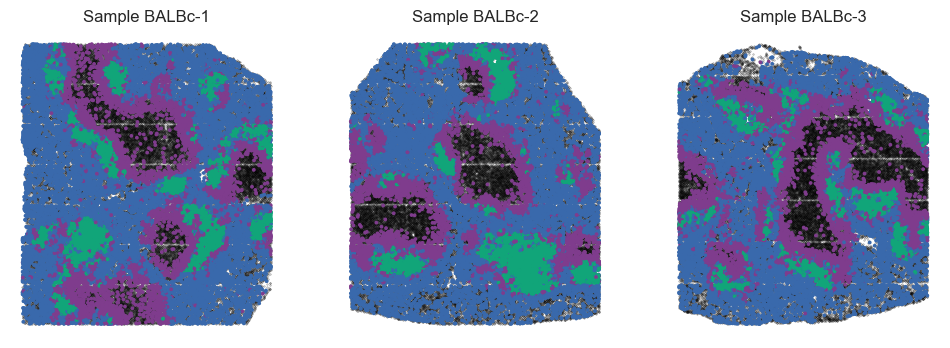

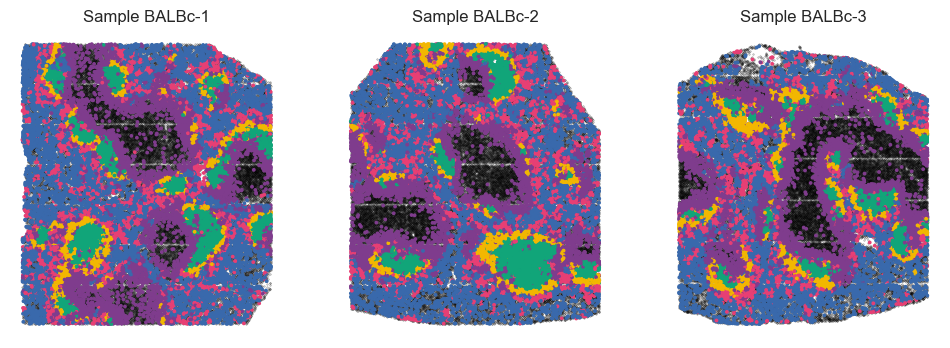

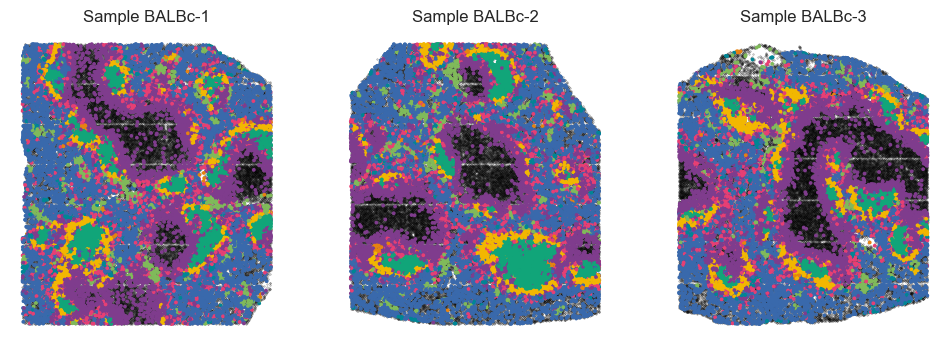

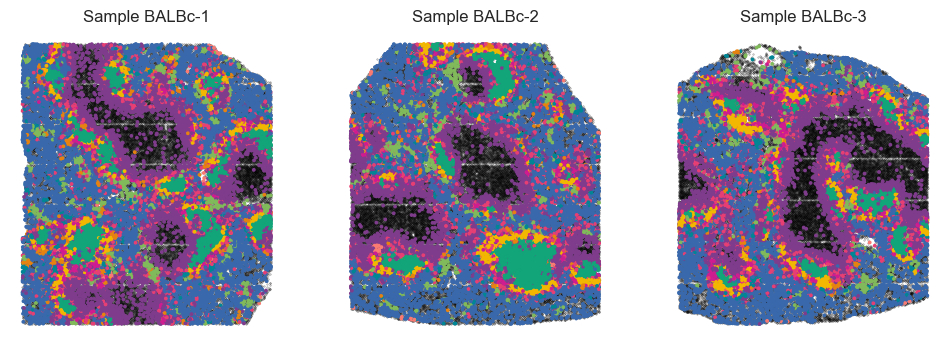

In [61]:
from spatial_lda.visualization import plot_samples_in_a_row
plot_samples_in_a_row(topic_weights_3, plot_bcell_topic_multicolor, spleen_dfs, tumor_set=samples)
plot_samples_in_a_row(topic_weights_5, plot_bcell_topic_multicolor, spleen_dfs, tumor_set=samples)
plot_samples_in_a_row(topic_weights_8, plot_bcell_topic_multicolor, spleen_dfs, tumor_set=samples)
plot_samples_in_a_row(topic_weights_10, plot_bcell_topic_multicolor, spleen_dfs, tumor_set=samples)

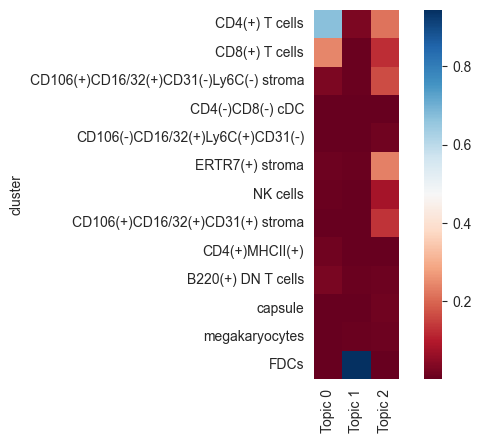

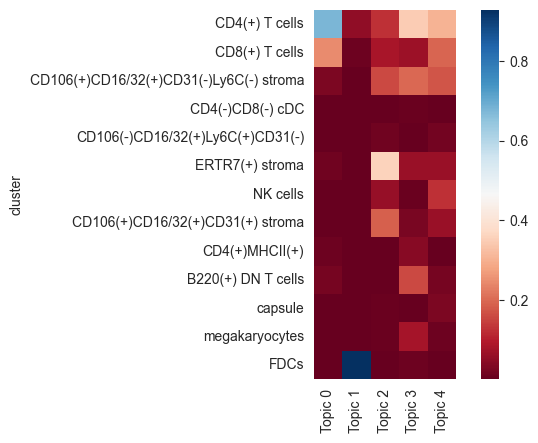

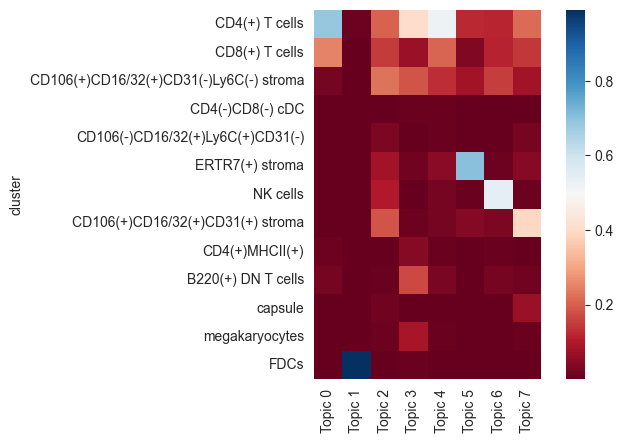

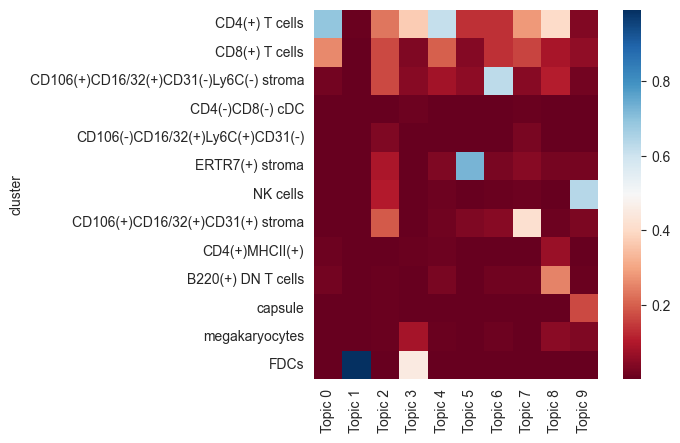

In [62]:
from spatial_lda.visualization import plot_topics_heatmap
idcs_take = [0,1,2,3,8,13,14,15,16,17,19,20,21]
normalizer = lambda ar: (ar/np.sum(ar, axis=1, keepdims=True)).T
plt.figure()
plot_topics_heatmap(lda_3.components_[:, idcs_take], spleen_cells_features.columns[idcs_take], normalizer)
plt.figure()
plot_topics_heatmap(lda_5.components_[:, idcs_take], spleen_cells_features.columns[idcs_take], normalizer)
plt.figure()
plot_topics_heatmap(lda_8.components_[:, idcs_take], spleen_cells_features.columns[idcs_take], normalizer)
plt.figure()
plot_topics_heatmap(lda_10.components_[:, idcs_take], spleen_cells_features.columns[idcs_take], normalizer)